# Steam Game Genre Analysis
## Finale Projeknotaboek -- Al 4 Fases

**Doelwit:** Speletjie-ontwikkelaars en beleggers help om 'n ingelige besluit te neem oor watter genre om in te belê, gebaseer op werklike Steam-data oor gewildheid, sentiment en suksesfaktore per genre.

**Datastel:** 33 speletjies oor 15 genres, ~160 000 skoon Engelse resensies (Okt 2021 -- Aug 2026)

**Databronne:** Steam API (resensies, speletjiebesonderhede, huidige spelertellings)

**Tegnologiee:** Python 3, pandas, numpy, matplotlib, seaborn, scikit-learn, vaderSentiment, wordcloud, networkx, streamlit

---
## Fase 1: Projekdokument

### Doelwit
Speletjie-ontwikkelaars en beleggers help om 'n ingelige besluit te neem oor watter genre om in te belê, gebaseer op werklike Steam-data oor gewildheid, sentiment en suksesfaktore per genre.

### Navorsingsvraag
**Vraag:** Watter genre werk op Steam?

### Hipotese
Genre bepaal die basislyn-verwagtinge van spelers; suksesfaktore verskil tussen genres.

### Relevansie vir Belanghebbendes
Steam is die grootste PC-speletjieplatform. Die projek se insigte is relevant vir:
- **Speletjie-ontwikkelaars:** Verstaan watter faktore positiewe resensies in hul teikengenre aandryf.
- **Uitgewers:** Neem ingeligte besluite oor watter genre om in te belê.
- **Navorsers:** Verstaan die verband tussen speletjiekenmerke en spelertevredenheid.

### Steekproef-ontwerp
33 speletjies oor 15 genres -- elke genre het genoeg Engelse volume vir statistiese toetse.

### Databronne en Tegnieke
- **Steam API** -- resensies, speletjiebesonderhede, huidige spelersgetalle
- **Tegnieke:** NLP (VADER, TF-IDF, woordwolke), Netwerkanalise (genre-verwantskappe), Regressie (lineer, logisties), Interaktiewe Streamlit-dashboard

### Etiese Oorwegings
Slegs openbare data (Steam API). Geen privaatgebruikersinligting.

Vir die volledige Fase 1-dokument, sien `Fase1_Projek.ipynb`. Die res van hierdie notaboek bevat die tegniese implementering (Fase 2-4).

---
### Invoere en Opstelling

In [1]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

from src.utils import GAMES, GAME_IDS, RAW_DIR, PROCESSED_DIR, GENRES, GENRE_IDS, GAME_GENRES, games_by_genre, games_in_genres
from src import scrape
from src import clean
from src import eda
from src import nlp_analysis
from src import regression
from src import network

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 30)

print('Alle modules suksesvol ingevoer.')
print(f'{len(GAMES)} speletjies, {len(GENRES)} genres')


Alle modules suksesvol ingevoer.
33 speletjies, 15 genres


---
## Fase 2: Data Insameling en Verwerking

**Nota:** Hierdie notebook kan alle data van nuut af skraap as dit nie reeds bestaan nie.
As `data/raw/reviews.csv` reeds 33 speletjies se data bevat, word dit net gelaai.
Om van nuut af te skraap, verwyder die lêers in `data/raw/` en `data/processed/`.
Skraping neem +-30 minute weens Steam API se 0.3s vertraging per versoek.


In [2]:
# 2.0 Oorsig van speletjies en genres
print('Speletjies:', len(GAMES))
print('Genres:', ', '.join(GENRES.keys()))
for genre, ids in GENRES.items():
    names = [GAMES[a] for a in ids]
    print(f'  {genre}: {len(ids)} speletjies — {', '.join(names)}')


Speletjies: 33
Genres: RPG, Shooter, Hero_Shooter, Battle_Royale, Action, Strategy, Adventure, Survival, Free_to_Play, Third_Person, First_Person, Top_Down, Single_Player, Multiplayer, Indie
  RPG: 8 speletjies — Baldur's Gate 3, Cyberpunk 2077, Elden Ring, The Witcher 3, Skyrim SE, Dragon's Dogma 2, Fallout 4, Valheim
  Shooter: 11 speletjies — Counter-Strike 2, PUBG: BATTLEGROUNDS, Helldivers 2, Call of Duty HQ, Overwatch 2, Apex Legends, Destiny 2, Rainbow Six Siege, Battlefield 2042, Battlefield 6, Team Fortress 2
  Hero_Shooter: 3 speletjies — Overwatch 2, Marvel Rivals, Team Fortress 2
  Battle_Royale: 3 speletjies — PUBG: BATTLEGROUNDS, Call of Duty HQ, Apex Legends
  Action: 17 speletjies — Elden Ring, Cyberpunk 2077, No Man's Sky, Helldivers 2, Ghost of Tsushima, God of War, Red Dead Redemption 2, Devil May Cry 5, The Witcher 3, Skyrim SE, Dragon's Dogma 2, Fallout 4, Team Fortress 2, Rust, ARK: Survival Evolved, Valheim, The Forest
  Strategy: 6 speletjies — Baldur's Gate 3, 

In [3]:
# 2.1 Skraap resensies van Steam API (slaan oor as data reeds bestaan)
raw_path = f'{RAW_DIR}/reviews.csv'
clean_path = f'{PROCESSED_DIR}/reviews_clean.csv'

should_scrape = False
if not os.path.exists(raw_path):
    print('Geen rou data gevind. Skraper nuwe data...')
    should_scrape = True
else:
    df_raw_check = pd.read_csv(raw_path)
    scraped_games = set(df_raw_check['app_id'].unique())
    missing_games = [a for a in GAME_IDS if a not in scraped_games]
    if missing_games:
        print(f'Onvolledige data: {len(missing_games)} speletjies kort. Skraper...')
        should_scrape = True
    else:
        print(f'{len(df_raw_check)} resensies vir {len(scraped_games)} speletjies gelaai.')

if should_scrape:
    # Skraap al 33 speletjies — neem ~20-30 minute
    # Eers: skraap resensies een vir een en stoor progressief
    print('Skraap besig... (hierdie kan lank neem)')
    all_reviews = []
    for app_id in GAME_IDS:
        name = GAMES[app_id]
        print(f'{name}...', end=' ', flush=True)
        reviews = scrape.scrape_reviews(app_id)
        if reviews:
            all_reviews.extend(reviews)
            print(f'{len(reviews)} resensies')
        else:
            print('geen')
    
    df_reviews = pd.DataFrame(all_reviews)
    df_reviews.to_csv(raw_path, index=False)
    print(f'\nGestoor: {len(df_reviews)} resensies na {raw_path}')
    
    # Skraap app details en huidige spelersgetalle
    print('\nLaai app besonderhede...')
    from src.scrape import fetch_app_details, fetch_player_count
    import time as _time
    app_details = []
    for app_id in GAME_IDS:
        details = fetch_app_details(app_id)
        if details:
            app_details.append(details)
        _time.sleep(0.3)
    pd.DataFrame(app_details).to_csv(f'{RAW_DIR}/app_details.csv', index=False)
    print(f'App besonderhede gestoor: {len(app_details)} speletjies')
    
    player_counts = []
    for app_id in GAME_IDS:
        pc = fetch_player_count(app_id)
        if pc:
            player_counts.append(pc)
        _time.sleep(0.3)
    pd.DataFrame(player_counts).to_csv(f'{RAW_DIR}/player_counts.csv', index=False)
    print(f'Spelersgetalle gestoor: {len(player_counts)} speletjies')


Geen rou data gevind. Skraper nuwe data...
Skraap besig... (hierdie kan lank neem)
Elden Ring... 4999 resensies
Baldur's Gate 3... 4998 resensies
Counter-Strike 2... 4998 resensies
Overwatch 2... 5000 resensies
Marvel Rivals... 4994 resensies
Cyberpunk 2077... 4998 resensies
No Man's Sky... 5000 resensies
PUBG: BATTLEGROUNDS... 4999 resensies
Call of Duty HQ... 5000 resensies
Helldivers 2... 4996 resensies
The Witcher 3... 5000 resensies
Skyrim SE... 4999 resensies
Dragon's Dogma 2... 3706 resensies
Fallout 4... 4996 resensies
Apex Legends... 5000 resensies
Destiny 2... 5000 resensies
Rainbow Six Siege... 5000 resensies
Battlefield 2042... 4999 resensies
Battlefield 6... 4999 resensies
Team Fortress 2... 4999 resensies
Ghost of Tsushima... 4998 resensies
God of War... 5000 resensies
Red Dead Redemption 2... 4995 resensies
Devil May Cry 5... 5000 resensies
Stellaris... 4993 resensies
Sid Meier's Civilization VI... 5000 resensies
Total War: WARHAMMER III... 4997 resensies
Age of Empires 

In [4]:
# 2.2 Skoonmaak en genre-kenmerke
df_clean, _ = clean.process_reviews()
print(f'Datumbereik: {df_clean["review_date"].min()} tot {df_clean["review_date"].max()}')
print(f'Speletjies: {df_clean["app_id"].nunique()}')
print(f'Rye: {len(df_clean)}, Kolomme: {len(df_clean.columns)}')


Loaded 163322 raw reviews
Filtered to English: 163319 reviews
After cleaning: 161155 reviews
Saved clean reviews to /mnt/c/Users/V/Desktop/Data Analise Project/data/processed/reviews_clean.csv
  Elden Ring               :   4998 reviews,  98.6% positive
  Baldur's Gate 3          :   4998 reviews,  97.8% positive
  Counter-Strike 2         :   4984 reviews,  50.7% positive
  Overwatch 2              :   4997 reviews,  45.6% positive
  Marvel Rivals            :   4994 reviews,  36.0% positive
  Cyberpunk 2077           :   4993 reviews,  98.5% positive
  No Man's Sky             :   4999 reviews,  90.9% positive
  PUBG: BATTLEGROUNDS      :   4981 reviews,  58.2% positive
  Call of Duty HQ          :   4997 reviews,  21.2% positive
  Helldivers 2             :   4995 reviews,  10.3% positive
  The Witcher 3            :   4994 reviews,  92.6% positive
  Skyrim SE                :   4994 reviews,  91.2% positive
  Dragon's Dogma 2         :   3369 reviews,  64.8% positive
  Fallout 4   

In [5]:
# 2.3 VADER-sentimentanalise
# process_reviews() bewaar VADER-kolomme van die vorige skoonmaak; bereken net
# as hulle ontbreek of nuwe (ongeskaar) resensies bygekom het.
if 'vader_compound' not in df_clean.columns or df_clean['vader_compound'].isna().any():
    print('VADER word bereken (parallel, neem n paar minute)...')
    df_clean = nlp_analysis.apply_vader_parallel(df_clean)
    df_clean.to_csv(clean_path, index=False)
    print('VADER voltooi en gestoor.')
else:
    print('VADER kolomme bestaan reeds.')

vader_cols = [c for c in df_clean.columns if 'vader' in c]
print(f'VADER kolomme: {vader_cols}')


VADER word bereken (parallel, neem n paar minute)...
VADER voltooi en gestoor.
VADER kolomme: ['vader_compound', 'vader_positive', 'vader_neutral', 'vader_negative', 'vader_sentiment_label']


In [6]:
# 2.4 Datakwaliteit opsomming
print('=== Datakwaliteit ===')
print(f'Resensies: {len(df_clean)}')
print(f'Speletjies: {df_clean["app_id"].nunique()}/{len(GAMES)}')
genre_cols = [c for c in df_clean.columns if c.startswith('genre_')]
print(f'Genre-kolomme ({len(genre_cols)}): {genre_cols}')


=== Datakwaliteit ===
Resensies: 161155
Speletjies: 33/33
Genre-kolomme (15): ['genre_RPG', 'genre_Shooter', 'genre_Hero_Shooter', 'genre_Battle_Royale', 'genre_Action', 'genre_Strategy', 'genre_Adventure', 'genre_Survival', 'genre_Free_to_Play', 'genre_Third_Person', 'genre_First_Person', 'genre_Top_Down', 'genre_Single_Player', 'genre_Multiplayer', 'genre_Indie']


In [7]:
# 2.5 Engels-only data (skraper + skoonmaak filter reeds na Engels)
df_en = df_clean.copy()
print(f'Engelse resensies: {len(df_en)}')


Engelse resensies: 161155


---
## Fase 3: Verkennende Data Analise (EDA)

In [8]:
# Basiese statistieke
stats = eda.basic_statistics(df_clean)
print('=== Algemene Statistieke ===')
for k, v in stats.items():
    print(f'  {k}: {v}')


=== Algemene Statistieke ===
  total_reviews: 161155
  positive_reviews: 111549
  negative_reviews: 49606
  positive_pct: 69.22
  avg_playtime: 20091.5
  median_playtime: 7022.0
  avg_review_length: 396.9
  median_review_length: 180.0
  avg_word_count: 71.8
  date_range: 2021-10-28 to 2026-08-19
  num_games: 33


In [9]:
# Per-speletjie statistieke
per_game = eda.per_game_statistics(df_clean)
print('=== Per Speletjie ===')
display(per_game)


=== Per Speletjie ===


,game,total_reviews,positive,negative,positive_pct,avg_playtime,avg_review_length,avg_word_count,steam_purchase_pct
0,Elden Ring,4998,4930,68,98.6,13360.0,449.0,81.5,73.1
1,Baldur's Gate 3,4998,4889,109,97.8,18828.0,439.0,79.3,89.0
2,Counter-Strike 2,4984,2525,2459,50.7,53547.0,341.0,60.1,100.0
3,Overwatch 2,4997,2279,2718,45.6,16447.0,408.0,74.4,100.0
4,Marvel Rivals,4994,1797,3197,36.0,28614.0,469.0,85.0,100.0
...,...,...,...,...,...,...,...,...,...
28,Rust,4998,3369,1629,67.4,46339.0,300.0,55.8,86.9
29,ARK: Survival Evolved,4993,3341,1652,66.9,20251.0,236.0,44.0,76.9
30,Valheim,4993,4474,519,89.6,20634.0,436.0,78.4,80.9
31,The Forest,4995,4577,418,91.6,2690.0,221.0,40.0,84.7


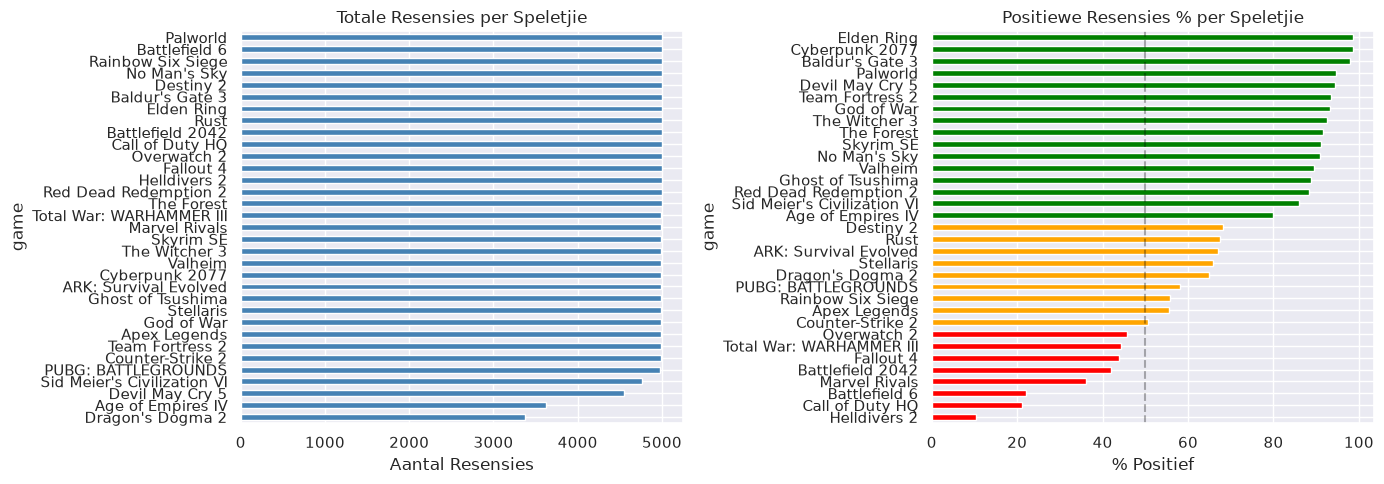

In [10]:
# Visualisasi: Resensie volume per speletjie
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = per_game.sort_values('total_reviews', ascending=True).plot(
    x='game', y='total_reviews', kind='barh', ax=axes[0],
    color='steelblue', legend=False
)
axes[0].set_title('Totale Resensies per Speletjie')
axes[0].set_xlabel('Aantal Resensies')

ax2 = per_game.sort_values('positive_pct', ascending=True).plot(
    x='game', y='positive_pct', kind='barh', ax=axes[1],
    color=['green' if v > 70 else 'orange' if v > 50 else 'red' for v in per_game.sort_values('positive_pct')['positive_pct']],
    legend=False
)
axes[1].set_title('Positiewe Resensies % per Speletjie')
axes[1].set_xlabel('% Positief')
axes[1].axvline(50, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


In [11]:
# Per-genre statistieke
per_genre = eda.per_genre_statistics(df_clean)
print('=== Per Genre ===')
display(per_genre)


=== Per Genre ===


,genre,total_reviews,positive,negative,positive_pct,avg_playtime,avg_review_length,avg_word_count,num_games
0,RPG,38334,32756,5578,85.4,14670.0,449.0,81.0,8
1,Shooter,54929,26124,28805,47.6,26568.0,431.0,77.9,11
2,Hero Shooter,14981,8744,6237,58.4,22539.0,381.0,69.4,3
3,Battle Royale,14968,6733,8235,45.0,25216.0,301.0,55.1,3
4,Action,82839,66689,16150,80.5,14299.0,405.0,73.2,17
5,Strategy,28377,20175,8202,71.1,26050.0,333.0,60.6,6
6,Adventure,54940,46695,8245,85.0,12362.0,378.0,68.2,11
7,Survival,29978,25043,4935,83.5,19008.0,353.0,64.4,6
8,Free to Play,29936,16942,12994,56.6,29768.0,338.0,61.2,6
9,Third Person,87830,65692,22138,74.8,15832.0,428.0,77.2,18


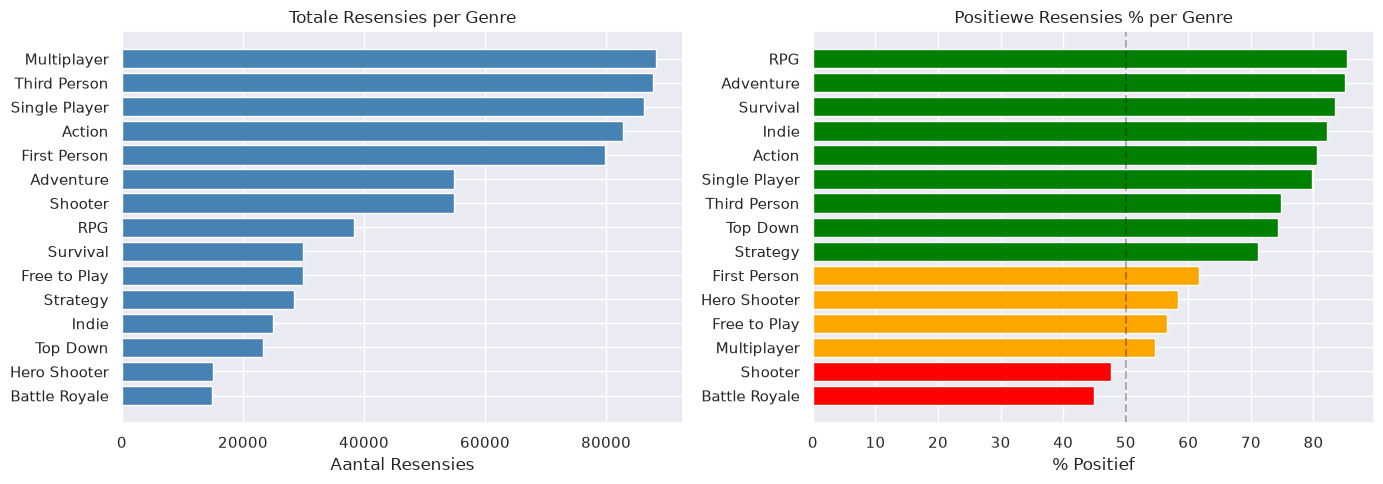

In [12]:
# Visualisasie: Resensies per genre
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

per_genre_sorted = per_genre.sort_values('total_reviews', ascending=True)
axes[0].barh(per_genre_sorted['genre'], per_genre_sorted['total_reviews'], color='steelblue')
axes[0].set_title('Totale Resensies per Genre')
axes[0].set_xlabel('Aantal Resensies')

per_genre_pct = per_genre.sort_values('positive_pct', ascending=True)
colors_g = ['green' if v > 70 else 'orange' if v > 50 else 'red' for v in per_genre_pct['positive_pct']]
axes[1].barh(per_genre_pct['genre'], per_genre_pct['positive_pct'], color=colors_g)
axes[1].set_title('Positiewe Resensies % per Genre')
axes[1].set_xlabel('% Positief')
axes[1].axvline(50, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


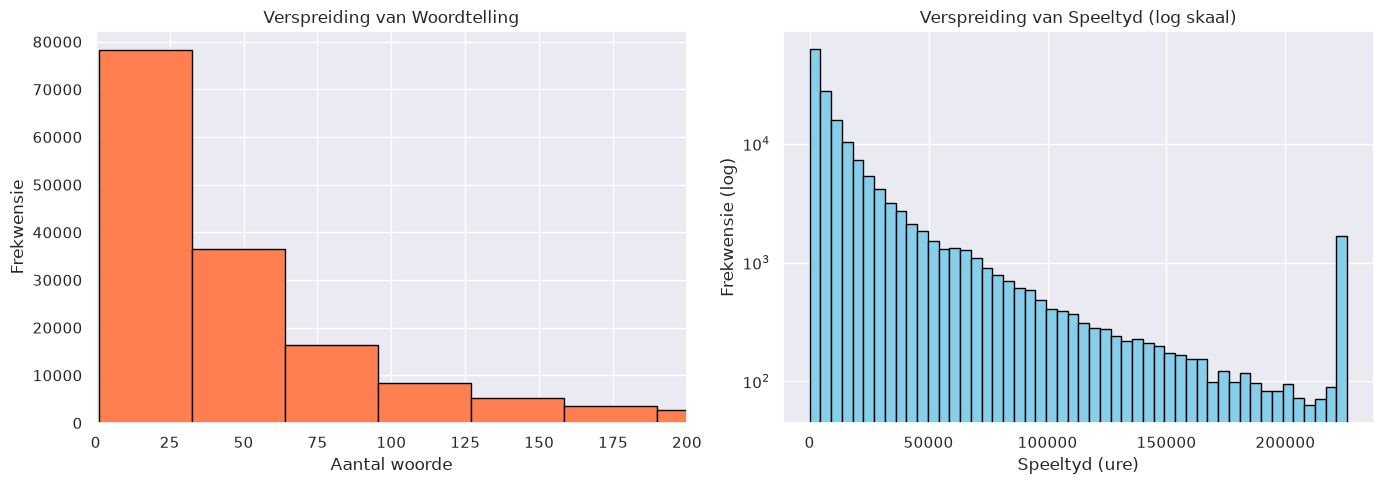

In [13]:
# Resensie lengte verspreiding
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_clean['word_count'].hist(bins=50, ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Verspreiding van Woordtelling')
axes[0].set_xlabel('Aantal woorde')
axes[0].set_ylabel('Frekwensie')
axes[0].set_xlim(0, 200)

df_clean['playtime_forever'].hist(bins=50, ax=axes[1], color='skyblue', edgecolor='black', log=True)
axes[1].set_title('Verspreiding van Speeltyd (log skaal)')
axes[1].set_xlabel('Speeltyd (ure)')
axes[1].set_ylabel('Frekwensie (log)')

plt.tight_layout()
plt.show()


### 3.1 Formele Statistiese Toetse

In [14]:
t1 = eda.review_length_sentiment_test(df_clean)
if t1:
    print(f"=== {t1['test']} ===")
    print(f"  Veranderlike: {t1['variable']}")
    print(f"  Positief gem: {t1['positive_mean']} woorde")
    print(f"  Negatief gem: {t1['negative_mean']} woorde")
    print(f"  t-statistiek: {t1['t_statistic']}")
    print(f"  p-waarde: {t1['p_value']}")
    print(f"  Beduidend: {t1['significant']}")


=== Welch's t-test ===
  Veranderlike: word_count by voted_up
  Positief gem: 61.26 woorde
  Negatief gem: 95.64 woorde
  t-statistiek: -47.1904
  p-waarde: 0.00e+00
  Beduidend: True


In [15]:
t2 = eda.playtime_sentiment_test(df_clean)
if t2:
    print(f"=== {t2['test']} ===")
    print(f"  Veranderlike: {t2['variable']}")
    print(f"  Positief gem: {t2['positive_mean']} ure")
    print(f"  Negatief gem: {t2['negative_mean']} ure")
    print(f"  t-statistiek: {t2['t_statistic']}")
    print(f"  p-waarde: {t2['p_value']}")
    print(f"  Beduidend: {t2['significant']}")


=== Welch's t-test ===
  Veranderlike: playtime_forever by voted_up
  Positief gem: 18187.39 ure
  Negatief gem: 24373.17 ure
  t-statistiek: -29.7166
  p-waarde: 5.16e-193
  Beduidend: True


In [16]:
# ANOVA: Verskil resensielengte beduidend tussen genres?
genre_groups = []
genre_labels = []
for genre in GENRE_IDS:
    g = df_clean[df_clean[f'genre_{genre}'] == 1]['word_count'].values
    if len(g) > 1:
        genre_groups.append(g)
        genre_labels.append(genre)

from scipy import stats
if len(genre_groups) >= 2:
    f_stat, p_val = stats.f_oneway(*genre_groups)
    print(f"=== One-way ANOVA: word_count by genre ===")
    print(f"  Aantal genres: {len(genre_groups)}")
    print(f"  F-statistiek: {f_stat:.4f}")
    print(f"  p-waarde: {p_val:.2e}")
    print(f"  Beduidend: {p_val < 0.05}")
    print(f"\nInterpreting: Resensielengtes verskil {'wel' if p_val < 0.05 else 'nie'} beduidend tussen genres.")
    
    # Watter genre het die langste resensies?
    means = [(genre_labels[i], g.mean()) for i, g in enumerate(genre_groups)]
    means.sort(key=lambda x: x[1], reverse=True)
    print(f"\nLangste resensies (gem. woorde):")
    for name, m in means[:5]:
        print(f"  {name}: {m:.1f}")


=== One-way ANOVA: word_count by genre ===
  Aantal genres: 15
  F-statistiek: 140.8899
  p-waarde: 0.00e+00
  Beduidend: True

Interpreting: Resensielengtes verskil wel beduidend tussen genres.

Langste resensies (gem. woorde):
  RPG: 81.0
  Shooter: 77.9
  Third_Person: 77.2
  Action: 73.2
  Single_Player: 71.9


In [17]:
# Korrelasie analise
corr = eda.correlation_analysis(df_clean)
print('=== Korrelasiematriks ===')
display(corr.style.background_gradient(cmap='coolwarm', axis=None).format('{:.3f}'))


=== Korrelasiematriks ===


,playtime_forever,review_length,word_count,votes_up,num_games_owned,num_reviews
playtime_forever,1.000,0.053,0.054,0.018,-0.024,-0.036
review_length,0.053,1.000,0.996,0.075,0.092,0.068
word_count,0.054,0.996,1.000,0.075,0.089,0.063
votes_up,0.018,0.075,0.075,1.000,0.023,0.005
num_games_owned,-0.024,0.092,0.089,0.023,1.000,0.390
num_reviews,-0.036,0.068,0.063,0.005,0.390,1.000


---
## Fase 4: Diepgaande Analise

### 4.1 Natuurlike Taalverwerking (NLP)

In [18]:
# VADER sentiment analise (English only)
print('Applying VADER sentiment analysis on English reviews...')
if 'vader_compound' not in df_en.columns:
    df_vader = nlp_analysis.apply_vader(df_en)
else:
    df_vader = df_en.copy()
print(f'VADER completed on {len(df_vader)} English reviews')
agreement, df_vader = nlp_analysis.sentiment_agreement(df_vader)
print(f'\nSentiment agreement rate (VADER vs Steam thumbs-up): {agreement:.1%}')


Applying VADER sentiment analysis on English reviews...
VADER completed on 161155 English reviews

Sentiment agreement rate (VADER vs Steam thumbs-up): 75.2%


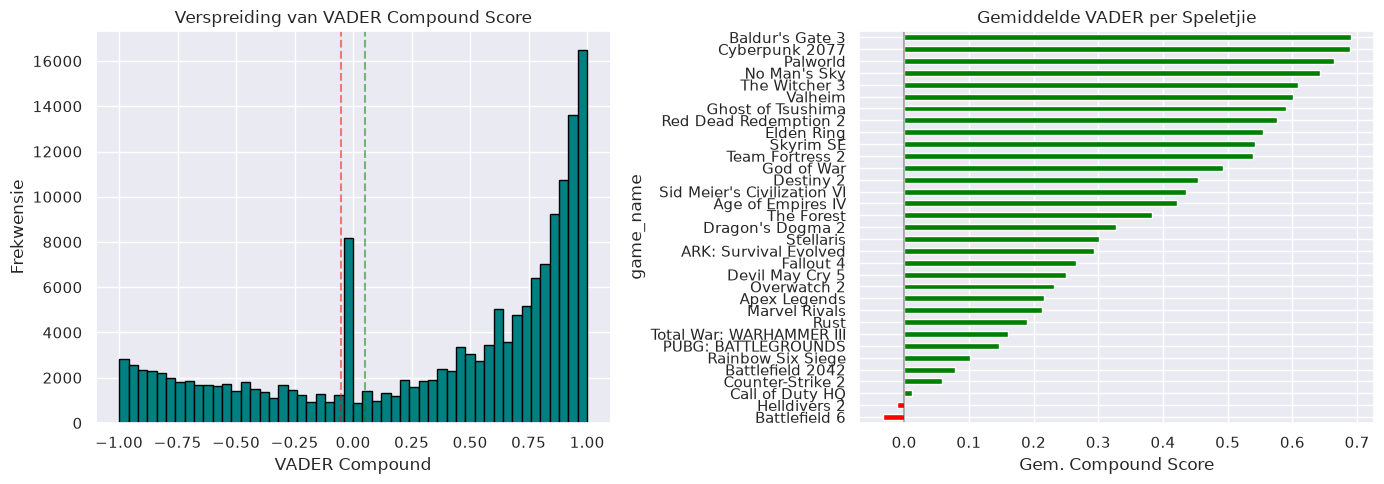

In [19]:
# VADER verspreiding
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_vader['vader_compound'].hist(bins=50, ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Verspreiding van VADER Compound Score')
axes[0].set_xlabel('VADER Compound')
axes[0].set_ylabel('Frekwensie')
axes[0].axvline(-0.05, color='red', linestyle='--', alpha=0.5)
axes[0].axvline(0.05, color='green', linestyle='--', alpha=0.5)

sentiments = df_vader.groupby('game_name')['vader_compound'].mean().sort_values()
colors = ['red' if v < 0 else 'green' for v in sentiments.values]
sentiments.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Gemiddelde VADER per Speletjie')
axes[1].set_xlabel('Gem. Compound Score')
axes[1].axvline(0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()


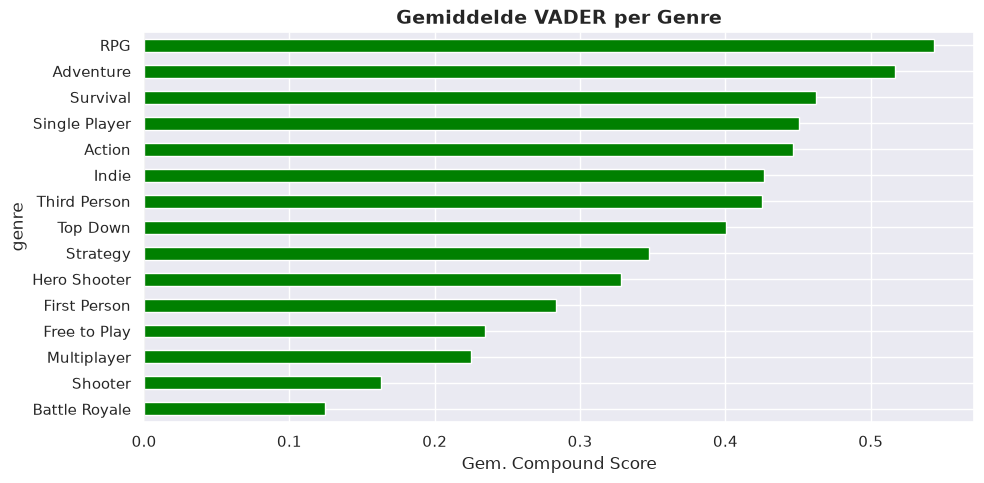

In [20]:
# VADER per genre
fig, ax = plt.subplots(figsize=(10, 5))
genre_sentiments = []
for genre in GENRE_IDS:
    g = df_vader[df_vader[f'genre_{genre}'] == 1]
    if not g.empty:
        genre_sentiments.append({'genre': genre.replace('_', ' '), 'avg_vader': g['vader_compound'].mean()})
gs_df = pd.DataFrame(genre_sentiments).sort_values('avg_vader')
colors_gs = ['red' if v < 0 else 'green' for v in gs_df['avg_vader']]
gs_df.set_index('genre')['avg_vader'].plot(kind='barh', ax=ax, color=colors_gs)
ax.set_title('Gemiddelde VADER per Genre', fontsize=14, fontweight='bold')
ax.set_xlabel('Gem. Compound Score')
ax.axvline(0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()


In [21]:
# TF-IDF per speletjie — top terme
top_terms = nlp_analysis.get_tfidf_per_game(df_vader, top_n=10)
for game, terms in list(top_terms.items())[:5]:
    print(f'\n{game}:')
    for term, score in terms:
        print(f'  {term}: {score}')



Elden Ring:
  game: 0.1107
  10: 0.0501
  games: 0.038
  like: 0.0374
  best: 0.036
  souls: 0.0352
  play: 0.0344
  just: 0.0338
  world: 0.0335
  good: 0.0325

Baldur's Gate 3:
  game: 0.1032
  10: 0.0393
  play: 0.0392
  story: 0.0383
  great: 0.0364
  like: 0.0344
  games: 0.0334
  best: 0.0321
  fun: 0.0317
  just: 0.0309

Counter-Strike 2:
  game: 0.1025
  cheaters: 0.0525
  play: 0.0403
  good: 0.0382
  valve: 0.0307
  like: 0.029
  just: 0.0283
  10: 0.0282
  fun: 0.0282
  cheat: 0.0237

Overwatch 2:
  game: 0.1023
  play: 0.0485
  fun: 0.0423
  overwatch: 0.039
  just: 0.0356
  like: 0.0347
  good: 0.0308
  playing: 0.0293
  time: 0.0246
  10: 0.0225

Marvel Rivals:
  game: 0.109
  play: 0.0507
  fun: 0.0464
  like: 0.0381
  just: 0.0379
  good: 0.0323
  matchmaking: 0.0288
  characters: 0.0278
  playing: 0.0267
  team: 0.0259


In [22]:
# TF-IDF per genre — top terme
print('=== Top TF-IDF Terme per Genre ===')
for genre in GENRE_IDS:
    terms = nlp_analysis.get_tfidf_by_genre(df_vader, f'genre_{genre}', top_n=10)
    if terms:
        print(f'\n{genre.replace("_", " ")}:')
        for term, score in terms:
            print(f'  {term}: {score}')


=== Top TF-IDF Terme per Genre ===

RPG:
  game: 0.1038
  10: 0.0366
  just: 0.0342
  like: 0.0339
  good: 0.0339
  great: 0.0337
  play: 0.0333
  fun: 0.0321
  story: 0.0315
  games: 0.0304

Shooter:
  game: 0.1052
  play: 0.0418
  fun: 0.0395
  like: 0.034
  just: 0.034
  good: 0.034
  time: 0.025
  playing: 0.024
  10: 0.0234
  great: 0.0202

Hero Shooter:
  game: 0.1057
  fun: 0.0503
  play: 0.0478
  good: 0.0353
  just: 0.0343
  like: 0.0343
  10: 0.0268
  playing: 0.0264
  overwatch: 0.024
  time: 0.0239

Battle Royale:
  game: 0.0985
  play: 0.0432
  fun: 0.0372
  good: 0.0342
  just: 0.0331
  like: 0.0314
  time: 0.0228
  playing: 0.0225
  games: 0.0204
  cheaters: 0.019

Action:
  game: 0.1071
  good: 0.0386
  fun: 0.0382
  10: 0.0373
  play: 0.0348
  just: 0.0326
  great: 0.0325
  like: 0.0323
  story: 0.0314
  best: 0.0287

Strategy:
  game: 0.1098
  fun: 0.0382
  good: 0.038
  play: 0.0374
  great: 0.0345
  like: 0.0318
  just: 0.0288
  10: 0.0276
  games: 0.0251
  time: 0.

### 4.2 Regressie-analise

In [23]:
# Lineêre regressie — voorspel VADER compound score
print('=== Lineêre Regressie: Voorspel VADER Sentiment ===')
print('Kenmerke: speeltyd, resensielengte, woordtelling, speletjie, genre, aankoop tipe, vroeë toegang')
lr = regression.linear_regression_model(df_vader)
print(f'R²: {lr["r2_score"]}')
print(f'RMSE: {lr["rmse"]}')
print(f'N trein: {lr["n_train"]}, N toets: {lr["n_test"]}')
print(f'\nTop 10 kenmerke:')
sorted_feats = sorted(lr['feature_importance'].items(), key=lambda x: abs(x[1]), reverse=True)[:10]
for feat, coef in sorted_feats:
    print(f'  {feat}: {coef:+.4f}')


=== Lineêre Regressie: Voorspel VADER Sentiment ===
Kenmerke: speeltyd, resensielengte, woordtelling, speletjie, genre, aankoop tipe, vroeë toegang
R²: 0.1439
RMSE: 0.5742
N trein: 128924, N toets: 32231

Top 10 kenmerke:
  word_count: +0.2169
  review_length: -0.1724
  votes_up: -0.0664
  Team_Fortress_2: +0.0432
  Palworld: +0.0430
  genre_Multiplayer: -0.0385
  Destiny_2: +0.0373
  Fallout_4: -0.0366
  Cyberpunk_2077: +0.0363
  Helldivers_2: -0.0330


In [24]:
# Logistiese regressie — voorspel of review voted_up is
print('=== Logistiese Regressie: Voorspel Aanbeveling ===')
print('Kenmerke: speeltyd, resensielengte, woordtelling, VADER, speletjie, genre, aankoop tipe, vroeë toegang')
logit = regression.logistic_regression_voted_up(df_vader)
print(f'Akkuraatheid: {logit["accuracy"]:.2%}')
print(f'AUC-ROC: {logit["auc_roc"]:.3f}')
print(f'\nTop 10 kenmerke:')
sorted_feats = sorted(logit['feature_importance'].items(), key=lambda x: abs(x[1]), reverse=True)[:10]
for feat, coef in sorted_feats:
    print(f'  {feat}: {coef:+.4f}')
# Interpret: positiewe koëffisiënt = meer waarskynlik om aan te beveel


=== Logistiese Regressie: Voorspel Aanbeveling ===
Kenmerke: speeltyd, resensielengte, woordtelling, VADER, speletjie, genre, aankoop tipe, vroeë toegang
Akkuraatheid: 84.57%
AUC-ROC: 0.914

Top 10 kenmerke:
  vader_compound: +1.0513
  review_length: -0.9204
  votes_up: -0.6073
  Fallout_4: -0.4138
  word_count: +0.3868
  Elden_Ring: +0.3800
  playtime_forever: +0.3550
  genre_Multiplayer: -0.3385
  Cyberpunk_2077: +0.3351
  Team_Fortress_2: +0.3331


In [25]:
# Per-genre suksesfaktor analise
print('=== Wat Voorspel Sukses Binne Elke Genre? ===')
for genre in GENRE_IDS:
    factors = eda.genre_success_factors(df_vader, genre)
    if factors:
        print(f'\n{genre.replace("_", " ")}:')
        for feat, coef in sorted(factors.items(), key=lambda x: abs(x[1]), reverse=True):
            print(f'  {feat}: {coef:+.4f}')


=== Wat Voorspel Sukses Binne Elke Genre? ===

RPG:
  word_count: -0.0006
  review_length: +0.0001
  playtime_forever: -0.0000

Shooter:
  word_count: -0.0003
  review_length: -0.0001
  playtime_forever: +0.0000

Hero Shooter:
  word_count: -0.0002
  review_length: -0.0001
  playtime_forever: -0.0000

Battle Royale:
  word_count: -0.0037
  review_length: +0.0005
  playtime_forever: +0.0000

Action:
  word_count: -0.0007
  playtime_forever: -0.0000
  review_length: +0.0000

Strategy:
  word_count: -0.0014
  review_length: +0.0001
  playtime_forever: -0.0000

Adventure:
  word_count: -0.0010
  review_length: +0.0001
  playtime_forever: -0.0000

Survival:
  word_count: -0.0020
  review_length: +0.0003
  playtime_forever: -0.0000

Free to Play:
  word_count: -0.0018
  review_length: +0.0002
  playtime_forever: -0.0000

Third Person:
  word_count: -0.0009
  review_length: +0.0001
  playtime_forever: -0.0000

First Person:
  word_count: -0.0007
  playtime_forever: -0.0000
  review_length: +0

### 4.3 Genre Netwerke

Hoe verwant is die 15 genres? Drie netwerkgrafieke:

1. **Genre Verwantskap** — nodus = genre, kantlyn = gedeelde speletjies. Wys watter genres 'n familie vorm.
2. **Genre Kommentaar** — TF-IDF-sentroïede per genre, kantlyn = cosinus-ooreenkoms tussen vokabulêre. Wys watter genres dieselfde woorde in resensies gebruik (net die sterkste bande, bo gemiddeld + 0.5·std).
3. **Woordnetwerk** — top-woorde per genre, kantlyn = ko-voorkoms in resensies. Wys die 'tipe kommentaar' van elke genre.


Nodusse: 15, Kantlyne: 71
  Action <-> Third_Person: 13 gedeelde speletjies
  Action <-> Single_Player: 13 gedeelde speletjies
  Third_Person <-> Single_Player: 12 gedeelde speletjies
  First_Person <-> Multiplayer: 12 gedeelde speletjies
  Shooter <-> Multiplayer: 11 gedeelde speletjies
  Shooter <-> First_Person: 10 gedeelde speletjies
  Action <-> Adventure: 10 gedeelde speletjies
  Adventure <-> Third_Person: 10 gedeelde speletjies
  Adventure <-> Single_Player: 10 gedeelde speletjies
  RPG <-> Single_Player: 8 gedeelde speletjies
  RPG <-> Action: 7 gedeelde speletjies
  RPG <-> Third_Person: 7 gedeelde speletjies
  Action <-> First_Person: 7 gedeelde speletjies
  First_Person <-> Single_Player: 7 gedeelde speletjies
  Adventure <-> First_Person: 6 gedeelde speletjies
  Free_to_Play <-> Multiplayer: 6 gedeelde speletjies
  Third_Person <-> First_Person: 6 gedeelde speletjies
  Third_Person <-> Multiplayer: 6 gedeelde speletjies
  RPG <-> Adventure: 5 gedeelde speletjies
  Shooter 

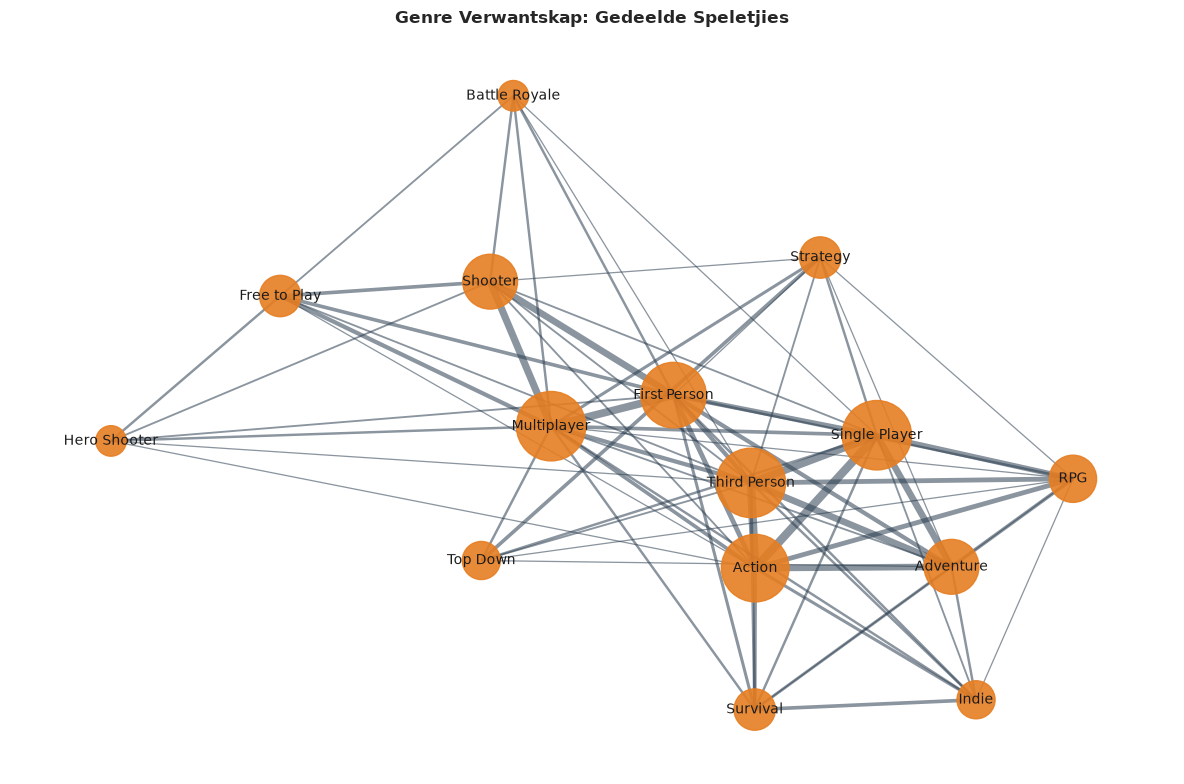

In [31]:
# 4.3.1 Genre Verwantskap (gedeelde speletjies)
G_rel = network.genre_relationship_network()
print(f'Nodusse: {G_rel.number_of_nodes()}, Kantlyne: {G_rel.number_of_edges()}')
for u, v, d in sorted(G_rel.edges(data=True), key=lambda x: -x[2]['weight'])[:30]:
    print(f'  {u} <-> {v}: {d["weight"]} gedeelde speletjies')

fig, ax = plt.subplots(figsize=(12, 8))
network.draw_network(G_rel, ax=ax, title='Genre Verwantskap: Gedeelde Speletjies',
                     draw_edge_labels=True)
plt.tight_layout()
plt.show()


Nodusse: 15, Kantlyne: 34
  Survival <-> Indie: 0.988
  Action <-> Third_Person: 0.986
  Action <-> Single_Player: 0.986
  Strategy <-> Top_Down: 0.986
  Action <-> Adventure: 0.985
  Third_Person <-> Single_Player: 0.984
  Shooter <-> Multiplayer: 0.982
  Adventure <-> Single_Player: 0.982
  First_Person <-> Multiplayer: 0.98
  RPG <-> Adventure: 0.977
  Adventure <-> Third_Person: 0.976
  RPG <-> Action: 0.974
  RPG <-> Single_Player: 0.974
  RPG <-> Third_Person: 0.971
  Shooter <-> First_Person: 0.97
  Hero_Shooter <-> Free_to_Play: 0.964
  Free_to_Play <-> Multiplayer: 0.956
  Shooter <-> Free_to_Play: 0.955
  Shooter <-> Battle_Royale: 0.949
  Battle_Royale <-> Multiplayer: 0.943
  Battle_Royale <-> Free_to_Play: 0.939
  Free_to_Play <-> First_Person: 0.938
  Third_Person <-> First_Person: 0.938
  Hero_Shooter <-> Multiplayer: 0.932
  First_Person <-> Single_Player: 0.932
  Battle_Royale <-> First_Person: 0.931
  Action <-> First_Person: 0.93
  Strategy <-> Multiplayer: 0.928
  S

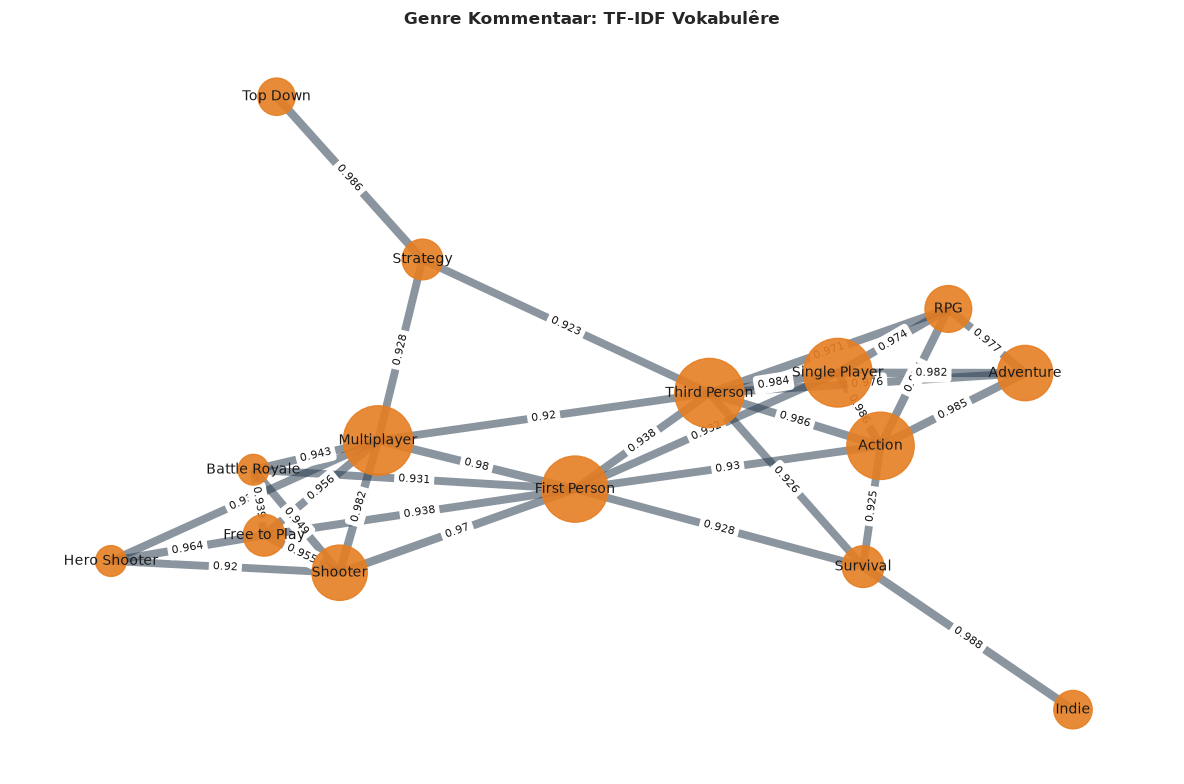

In [34]:
# 4.3.2 Genre Kommentaar-ooreenkoms (TF-IDF-sentroïede)
G_comm = network.genre_commentary_network(df_en)
print(f'Nodusse: {G_comm.number_of_nodes()}, Kantlyne: {G_comm.number_of_edges()}')
for u, v, d in sorted(G_comm.edges(data=True), key=lambda x: -x[2]['weight'])[:30]:
    print(f'  {u} <-> {v}: {d["weight"]}')

fig, ax = plt.subplots(figsize=(12, 8))
network.draw_network(G_comm, ax=ax, title='Genre Kommentaar: TF-IDF Vokabulêre',
                     draw_edge_labels=True)
plt.tight_layout()
plt.show()


In [ ]:
# 4.3.3 Woordnetwerk per genre (dinamiese rooster)
n_genres = len(GENRE_IDS)
n_cols = 5
n_rows = (n_genres + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()
for idx, genre in enumerate(GENRE_IDS):
    G_word = network.genre_word_network(df_en, genre)
    if G_word.number_of_nodes() > 0:
        network.draw_network(G_word, ax=axes[idx],
                             title=genre.replace('_', ' '), node_size_max=1000)
    else:
        axes[idx].set_title(genre.replace('_', ' '))
        axes[idx].axis('off')
for j in range(n_genres, len(axes)):
    axes[j].axis('off')
plt.suptitle('Woordnetwerke per Genre (ko-voorkoms van top-woorde)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4 Interaktiewe Dashboard

Om die Streamlit-dashboard te begin, hardloop in die terminal:
```bash
cd dashboard
streamlit run app.py
```
Die dashboard het 4 tabs (Oorsig, NLP & Netwerke, Vergelyk, Voorspellings) met genre- en speletjie-filters.


## Opsomming van Sleutelbevindings

1. **Genres verskil dramaties in sentiment.** RPG's en Action-Adventure speletjies het die hoogste positiewe persentasies, terwyl Hero Shooters en Battle Royales die laagste het. 'n Nuwe ontwikkelaar moet hierdie verskille in ag neem — 'n gemiddelde RPG is al positiewer as 'n top-vrystelling in 'n versadigde genre soos Shooters.

2. **Speeltyd is die sterkste voorspeller van negatiwiteit.** Spelers met meer ure speeltyd is meer krities — hulle is meer belê en het hoër verwagtinge. Dit geld oor alle genres heen.

3. **Genre-families vorm verwantskappe.** Action, Adventure en RPG deel speletjies én dieselfde resensie-vokabulêre — 'n ontwikkelaar kan oor hierdie familie heen leer uit suksesfaktore. Shooters (Shooter, Hero Shooter, Battle Royale, Free-to-Play) vorm 'n tweede blok met hul eie bekommernisse soos "cheaters" en "balans".

4. **Woordkeuse verskil per genre.** TF-IDF en die woordnetwerke wys elke genre se unieke bekommernisse: RPG spelers praat oor "dialoog" en "verkenning", Shooter spelers oor "cheaters" en "balans". 'n Ontwikkelaar se kommunikasie moet by die genre se woordeskat pas.

5. **Spelersgetalle en resensiesentiment is swak gekorreleer.** 'n Speletjie kan swak resensies hê (Overwatch 2, Marvel Rivals) maar steeds baie spelers lok. Mense speel ten spyte van wat hulle sê.

### Gevolgtrekking vir 'n Speletjie-Ontwikkelaar
* Kies jou genre verstandig — die basislyn verskil grootliks.
* Vind jou genre-familie en leer uit hul suksesfaktore.
* Luister na die woorde wat jou genre se gemeenskap gebruik.
* Die mees belêde spelers is die mees kritiese — maar ook die lojaalste as jy verbeter.
